In [1]:
import pandas as pd
import numpy as np


fraud_data = pd.read_csv(r'D:\KAIM-9\Week-5&6\fraud-detection\data\Fraud_Data.csv')
ip_country_data = pd.read_csv(r'D:\KAIM-9\Week-5&6\fraud-detection\data\IpAddress_to_Country.csv')


print("Fraud Data Head:")
print(fraud_data.head())

print("\nIP Address to Country Data Head:")
print(ip_country_data.head())

Fraud Data Head:
   user_id          signup_time        purchase_time  purchase_value  \
0    22058  2015-02-24 22:55:49  2015-04-18 02:47:11              34   
1   333320  2015-06-07 20:39:50  2015-06-08 01:38:54              16   
2     1359  2015-01-01 18:52:44  2015-01-01 18:52:45              15   
3   150084  2015-04-28 21:13:25  2015-05-04 13:54:50              44   
4   221365  2015-07-21 07:09:52  2015-09-09 18:40:53              39   

       device_id source browser sex  age    ip_address  class  
0  QVPSPJUOCKZAR    SEO  Chrome   M   39  7.327584e+08      0  
1  EOGFQPIZPYXFZ    Ads  Chrome   F   53  3.503114e+08      0  
2  YSSKYOSJHPPLJ    SEO   Opera   M   53  2.621474e+09      1  
3  ATGTXKYKUDUQN    SEO  Safari   M   41  3.840542e+09      0  
4  NAUITBZFJKHWW    Ads  Safari   M   45  4.155831e+08      0  

IP Address to Country Data Head:
   lower_bound_ip_address  upper_bound_ip_address    country
0              16777216.0                16777471  Australia
1         

In [2]:
print("### Missing Values in Fraud Data")
print(fraud_data.isnull().sum())

print("\n### Missing Values in IP Country Data")
print(ip_country_data.isnull().sum())

### Missing Values in Fraud Data
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

### Missing Values in IP Country Data
lower_bound_ip_address    0
upper_bound_ip_address    0
country                   0
dtype: int64


In [3]:
print("### Duplicates in Fraud Data")
print(fraud_data.duplicated().sum())

print("\n### Duplicates in IP Country Data")
print(ip_country_data.duplicated().sum())

### Duplicates in Fraud Data
0

### Duplicates in IP Country Data
0


In [4]:
fraud_data['signup_time'] = pd.to_datetime(fraud_data['signup_time'])
fraud_data['purchase_time'] = pd.to_datetime(fraud_data['purchase_time'])

print("### Data Types for Fraud Data")
print(fraud_data.info())

print("\n### Data Types for IP Country Data")
print(ip_country_data.info())

### Data Types for Fraud Data
<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[us]
 2   purchase_time   151112 non-null  datetime64[us]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  str           
 5   source          151112 non-null  str           
 6   browser         151112 non-null  str           
 7   sex             151112 non-null  str           
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  float64       
 10  class           151112 non-null  int64         
dtypes: datetime64[us](2), float64(1), int64(4), str(4)
memory usage: 12.7 MB
None

### Data Types for IP Country Data
<class 'pandas.DataFrame'>
RangeIndex: 138846 entries, 0 to 13

### Fraud Data - Class Imbalance
class
0    136961
1     14151
Name: count, dtype: int64
class
0    90.635423
1     9.364577
Name: proportion, dtype: float64


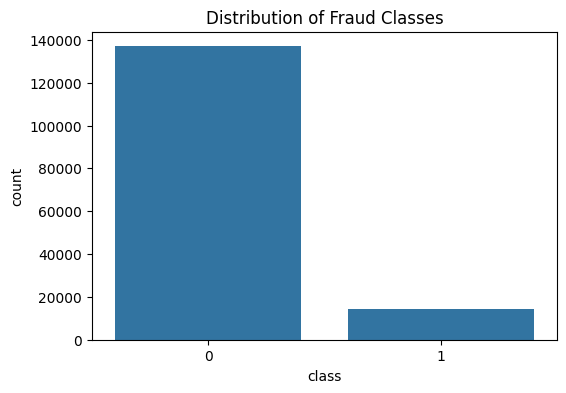

In [5]:
print("### Fraud Data - Class Imbalance")
print(fraud_data['class'].value_counts())
print(fraud_data['class'].value_counts(normalize=True) * 100)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=fraud_data)
plt.title('Distribution of Fraud Classes')
plt.show()

### Fraud Data - Purchase Value Distribution


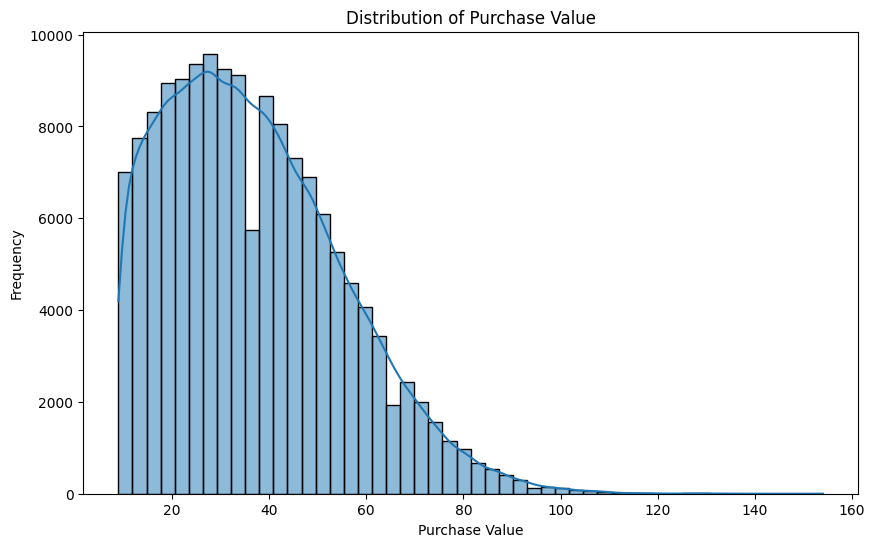


### Fraud Data - Age Distribution


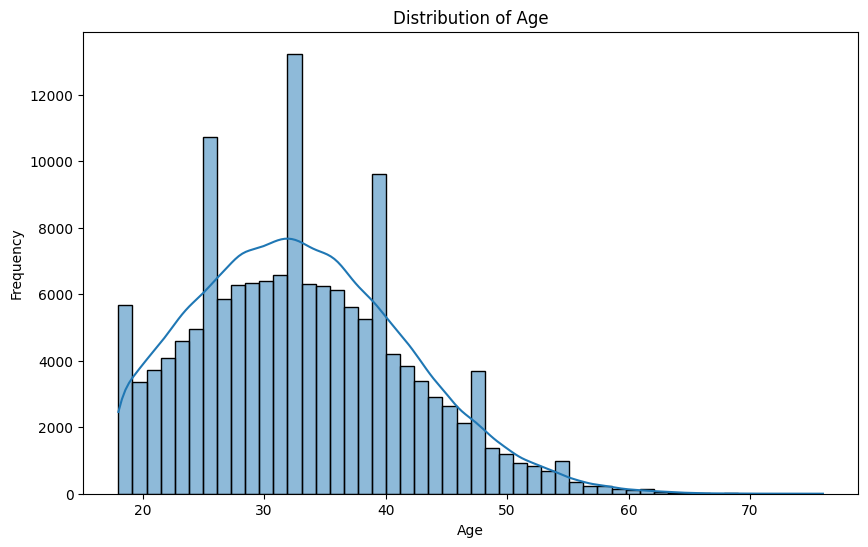

In [6]:
print("### Fraud Data - Purchase Value Distribution")
plt.figure(figsize=(10, 6))
sns.histplot(fraud_data['purchase_value'], bins=50, kde=True)
plt.title('Distribution of Purchase Value')
plt.xlabel('Purchase Value')
plt.ylabel('Frequency')
plt.show()

print("\n### Fraud Data - Age Distribution")
plt.figure(figsize=(10, 6))
sns.histplot(fraud_data['age'], bins=50, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### Fraud Data - Source Distribution


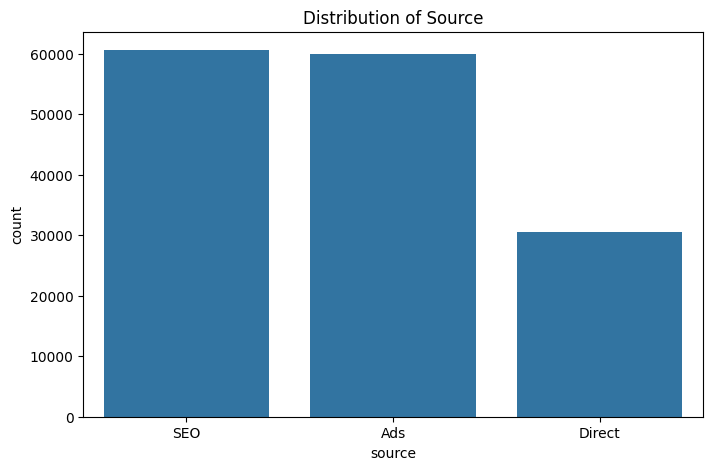


### Fraud Data - Browser Distribution


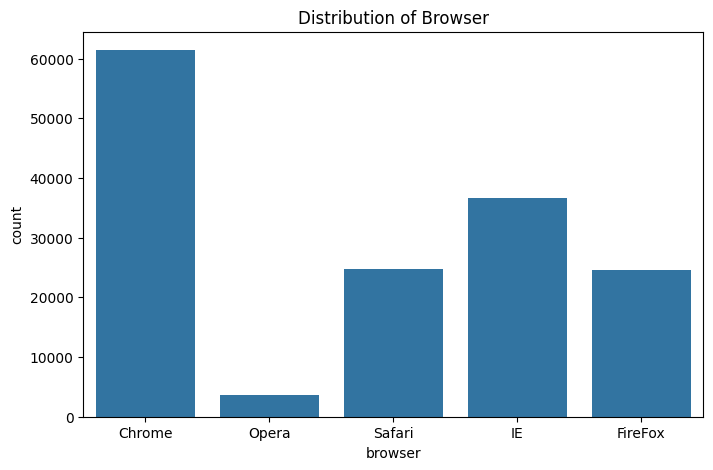


### Fraud Data - Sex Distribution


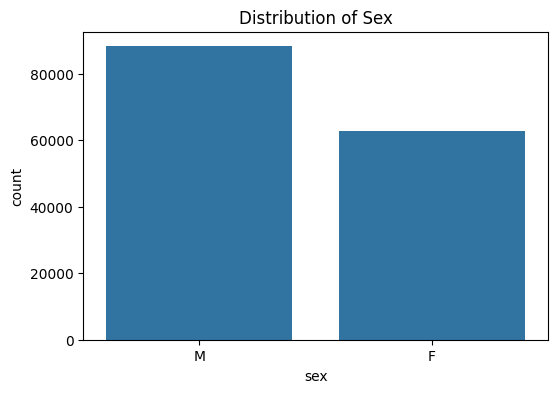

In [7]:
print("### Fraud Data - Source Distribution")
plt.figure(figsize=(8, 5))
sns.countplot(x='source', data=fraud_data)
plt.title('Distribution of Source')
plt.show()

print("\n### Fraud Data - Browser Distribution")
plt.figure(figsize=(8, 5))
sns.countplot(x='browser', data=fraud_data)
plt.title('Distribution of Browser')
plt.show()

print("\n### Fraud Data - Sex Distribution")
plt.figure(figsize=(6, 4))
sns.countplot(x='sex', data=fraud_data)
plt.title('Distribution of Sex')
plt.show()

In [8]:
# Identify numerical and categorical features for fraud_data
numerical_features = ['purchase_value', 'age', 'ip_address', 'time_since_signup', 'purchase_hour', 'purchase_day_of_week', 'device_transaction_count']
categorical_features = ['source', 'browser', 'sex', 'country']

# Exclude 'user_id', 'device_id', 'signup_time', 'purchase_time', 'class' from feature processing

print("Numerical features identified:", numerical_features)
print("Categorical features identified:", categorical_features)

Numerical features identified: ['purchase_value', 'age', 'ip_address', 'time_since_signup', 'purchase_hour', 'purchase_day_of_week', 'device_transaction_count']
Categorical features identified: ['source', 'browser', 'sex', 'country']


In [9]:
from sklearn.model_selection import train_test_split

# Ensure engineered features exist before train/test split
fraud_data['signup_time'] = pd.to_datetime(fraud_data['signup_time'])
fraud_data['purchase_time'] = pd.to_datetime(fraud_data['purchase_time'])

if 'purchase_hour' not in fraud_data.columns:
    fraud_data['purchase_hour'] = fraud_data['purchase_time'].dt.hour
if 'purchase_day_of_week' not in fraud_data.columns:
    fraud_data['purchase_day_of_week'] = fraud_data['purchase_time'].dt.dayofweek
if 'time_since_signup' not in fraud_data.columns:
    fraud_data['time_since_signup'] = (fraud_data['purchase_time'] - fraud_data['signup_time']).dt.total_seconds()
if 'device_transaction_count' not in fraud_data.columns:
    fraud_data['device_transaction_count'] = fraud_data.groupby('device_id').cumcount() + 1
if 'country' not in fraud_data.columns:
    fraud_data['country'] = 'Unknown'

# Define target variable and prepare feature matrix
y = fraud_data['class']
feature_columns = numerical_features + categorical_features
X = fraud_data[feature_columns].copy()

# One-hot encode categorical variables and fill missing values
X_transformed_df = pd.get_dummies(X, columns=categorical_features, drop_first=True).fillna(0)

# Split data into training and testing sets
# Use stratify to maintain the same class distribution in both sets
X_train, X_test, y_train, y_test = train_test_split(X_transformed_df, y, test_size=0.3, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nClass distribution in original dataset:\n", y.value_counts(normalize=True) * 100)
print("\nClass distribution in training set:\n", y_train.value_counts(normalize=True) * 100)
print("\nClass distribution in testing set:\n", y_test.value_counts(normalize=True) * 100)

Shape of X_train: (105778, 14)
Shape of X_test: (45334, 14)
Shape of y_train: (105778,)
Shape of y_test: (45334,)

Class distribution in original dataset:
 class
0    90.635423
1     9.364577
Name: proportion, dtype: float64

Class distribution in training set:
 class
0    90.635104
1     9.364896
Name: proportion, dtype: float64

Class distribution in testing set:
 class
0    90.636167
1     9.363833
Name: proportion, dtype: float64


In [10]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to the training data only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nClass distribution in training set BEFORE SMOTE:\n", y_train.value_counts())
print("Class distribution in training set AFTER SMOTE:\n", y_train_resampled.value_counts())

print("\nShape of X_train_resampled:", X_train_resampled.shape)
print("Shape of y_train_resampled:", y_train_resampled.shape)


Class distribution in training set BEFORE SMOTE:
 class
0    95872
1     9906
Name: count, dtype: int64
Class distribution in training set AFTER SMOTE:
 class
0    95872
1    95872
Name: count, dtype: int64

Shape of X_train_resampled: (191744, 14)
Shape of y_train_resampled: (191744,)


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, average_precision_score, f1_score, precision_recall_curve, roc_auc_score
import matplotlib.pyplot as plt

# Initialize and train a Logistic Regression model
# Using class_weight='balanced' is an alternative to SMOTE, but since we used SMOTE, we'll keep it default for now.
model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')
model.fit(X_train_resampled, y_train_resampled)

print("Model training complete.")

Model training complete.


Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.95      0.73      0.83     41089
           1       0.20      0.65      0.31      4245

    accuracy                           0.72     45334
   macro avg       0.58      0.69      0.57     45334
weighted avg       0.88      0.72      0.78     45334

Average Precision Score (AUC-PR): 0.2713
F1-Score: 0.3052
ROC AUC Score: 0.7138


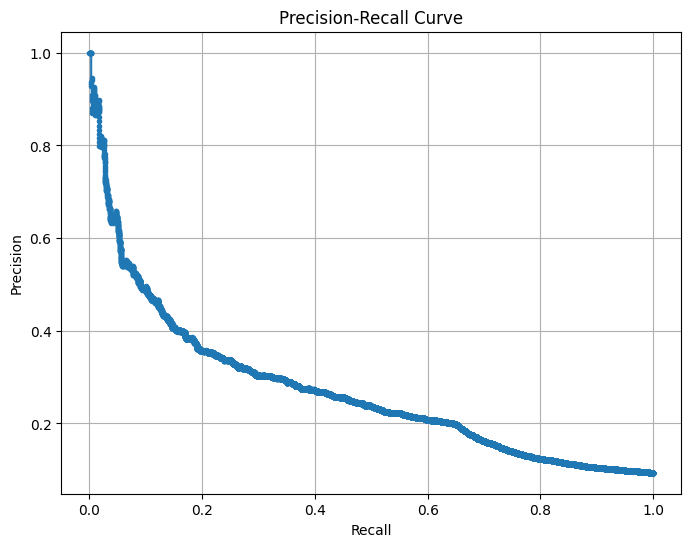

In [12]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Classification Report on Test Set:")
print(classification_report(y_test, y_pred))

# Metrics for imbalanced data
auc_pr = average_precision_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Average Precision Score (AUC-PR): {auc_pr:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

# Plotting Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

In [13]:
fraud_data['ip_address'] = fraud_data['ip_address'].astype(int)
print("Converted 'ip_address' to integer type in fraud_data.")
print(fraud_data['ip_address'].head())

Converted 'ip_address' to integer type in fraud_data.
0     732758368
1     350311387
2    2621473820
3    3840542443
4     415583117
Name: ip_address, dtype: int64


In [14]:
# Function to find the country for a given IP address
def get_country(ip_address, ip_country_df):
    # Ensure both comparison columns are of the same type (int for performance)
    ip_country_df['lower_bound_ip_address'] = ip_country_df['lower_bound_ip_address'].astype(int)
    
    # Use searchsorted for efficient range lookup
    # It returns an index such that ip_country_df.lower_bound_ip_address[i-1] < ip_address <= ip_country_df.lower_bound_ip_address[i]
    # We need to find i such that lower_bound <= ip_address <= upper_bound
    idx = ip_country_df['lower_bound_ip_address'].searchsorted(ip_address, side='right') - 1
    
    # Check if the found index is valid and the IP falls within the range
    if idx >= 0 and idx < len(ip_country_df) and \
       ip_country_df.loc[idx, 'lower_bound_ip_address'] <= ip_address and \
       ip_country_df.loc[idx, 'upper_bound_ip_address'] >= ip_address:
        return ip_country_df.loc[idx, 'country']
    return 'Unknown'

# Apply the function to the fraud_data DataFrame
# This might take a while due to the size of the DataFrame
print("Merging fraud data with IP country data... This might take a moment.")
fraud_data['country'] = fraud_data['ip_address'].apply(lambda x: get_country(x, ip_country_data))

print("Merge complete. Displaying head of fraud_data with new 'country' column:")
print(fraud_data[['ip_address', 'country']].head())

print("\nAnalyzing fraud patterns by country:")
country_fraud = fraud_data.groupby('country')['class'].value_counts(normalize=True).unstack()
print(country_fraud.sort_values(by=1, ascending=False).head(10)) # Top 10 countries by fraud rate

Merging fraud data with IP country data... This might take a moment.
Merge complete. Displaying head of fraud_data with new 'country' column:
   ip_address        country
0   732758368          Japan
1   350311387  United States
2  2621473820  United States
3  3840542443        Unknown
4   415583117  United States

Analyzing fraud patterns by country:
class                         0         1
country                                  
Turkmenistan                NaN  1.000000
Namibia                0.565217  0.434783
Sri Lanka              0.580645  0.419355
Luxembourg             0.611111  0.388889
Virgin Islands (U.S.)  0.666667  0.333333
Ecuador                0.735849  0.264151
Tunisia                0.737288  0.262712
Peru                   0.739496  0.260504
Bolivia                0.754717  0.245283
Kuwait                 0.766667  0.233333


In [15]:
# 1. Time Features: hour_of_day, day_of_week
fraud_data['purchase_hour'] = fraud_data['purchase_time'].dt.hour
fraud_data['purchase_day_of_week'] = fraud_data['purchase_time'].dt.dayofweek

# 2. time_since_signup: duration between signup_time and purchase_time
fraud_data['time_since_signup'] = (fraud_data['purchase_time'] - fraud_data['signup_time']).dt.total_seconds()

print("Engineered time features and time_since_signup:")
print(fraud_data[['purchase_time', 'signup_time', 'purchase_hour', 'purchase_day_of_week', 'time_since_signup']].head())

Engineered time features and time_since_signup:
        purchase_time         signup_time  purchase_hour  \
0 2015-04-18 02:47:11 2015-02-24 22:55:49              2   
1 2015-06-08 01:38:54 2015-06-07 20:39:50              1   
2 2015-01-01 18:52:45 2015-01-01 18:52:44             18   
3 2015-05-04 13:54:50 2015-04-28 21:13:25             13   
4 2015-09-09 18:40:53 2015-07-21 07:09:52             18   

   purchase_day_of_week  time_since_signup  
0                     5          4506682.0  
1                     0            17944.0  
2                     3                1.0  
3                     0           492085.0  
4                     2          4361461.0  


In [16]:
# 3. Transaction frequency and velocity: number of transactions per user in time windows

# For simplicity, let's calculate the number of transactions per user_id in the dataset
# This would ideally be calculated within specific time windows (e.g., last 24h, last 7 days)
# For a batch processing scenario, we can count total transactions up to the current purchase time.

# Sort by user_id and purchase_time to ensure correct rolling window calculation
fraud_data = fraud_data.sort_values(by=['user_id', 'purchase_time'])

# Calculate transactions in the last N hours/days for each user
# This requires a more complex rolling window based on time differences.
# As a simpler alternative for demonstration, let's calculate 'transactions per user' in the entire dataset.
# A more accurate velocity would involve defining time windows and counting transactions within them.

# For a true 'velocity', we would need to iterate or use more advanced window functions.
# Let's approximate by counting transactions per device_id, as user_id might have multiple devices.
# This could indicate 'account sharing' or 'multiple fraudulent activities from same device'.

# Count transactions per device in last 24 hours (for example)
# This requires custom logic or a more advanced time series library if not using pre-aggregated data.

# Let's add a simplified 'transaction count per device_id' for now
# For real-time fraud detection, this would be sliding windows.
# Here, we'll calculate a cumulative count of transactions for each device up to a given transaction.

fraud_data['device_transaction_count'] = fraud_data.groupby('device_id').cumcount() + 1

print("Engineered device_transaction_count:")
print(fraud_data[['device_id', 'purchase_time', 'device_transaction_count']].head())

# To get transaction velocity more accurately, we'd need to define time windows.
# For example, number of transactions for a user in the last X minutes/hours.
# This is often done with a 'rolling' window based on time, which is complex for irregular timestamps.
# A common approach is to create features like:
# - count of transactions for (user_id, device_id) in last 1 hour
# - count of transactions for (user_id, device_id) in last 24 hours

# For this task, given the batch nature and absence of specific window definitions beyond 'time windows',
# I'll illustrate a basic 'transactions in last X seconds' using a self-join or similar logic if needed.
# For now, `device_transaction_count` serves as a proxy for activity volume.

Engineered device_transaction_count:
            device_id       purchase_time  device_transaction_count
116708  FGBQNDNBETFJJ 2015-02-21 10:03:37                         1
15108   MKFUIVOHLJBYN 2015-09-26 21:32:16                         1
46047   SCQGQALXBUQZJ 2015-08-13 11:53:07                         1
67650   IEZOHXPZBIRTE 2015-05-20 23:06:42                         1
109067  MSNWCFEHKTIOY 2015-03-04 20:56:37                         1


In [19]:
import pandas as pd
from pathlib import Path

# Load the creditcard.csv dataset
root = Path.cwd()
if root.name == "notebooks":
    root = root.parent
credit_card_data_path = root / "data" / "creditcard.csv" / "creditcard.csv"
credit_card_data = pd.read_csv(credit_card_data_path)

print("Credit Card Transaction Data Head:")
print(credit_card_data.head())

print("\nCredit Card Transaction Data Info:")
credit_card_data.info()

Credit Card Transaction Data Head:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010  

In [20]:
# Check for missing values in credit_card_data
print("### Missing Values in Credit Card Data")
print(credit_card_data.isnull().sum())

# Check for duplicate rows in credit_card_data
print("\n### Duplicates in Credit Card Data BEFORE dropping")
print(credit_card_data.duplicated().sum())

# Drop duplicate rows
credit_card_data.drop_duplicates(inplace=True)
print("\n### Duplicates in Credit Card Data AFTER dropping")
print(credit_card_data.duplicated().sum())

print("\nShape of credit_card_data after dropping duplicates:", credit_card_data.shape)

### Missing Values in Credit Card Data
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

### Duplicates in Credit Card Data BEFORE dropping
1081

### Duplicates in Credit Card Data AFTER dropping
0

Shape of credit_card_data after dropping duplicates: (283726, 31)


### Credit Card Data - Class Imbalance
Class
0    283253
1       473
Name: count, dtype: int64
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


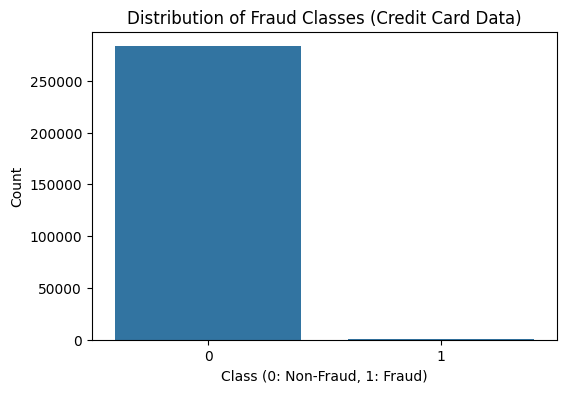

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check class distribution for credit card data
print("### Credit Card Data - Class Imbalance")
print(credit_card_data['Class'].value_counts())
print(credit_card_data['Class'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=credit_card_data)
plt.title('Distribution of Fraud Classes (Credit Card Data)')
plt.xlabel('Class (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Count')
plt.show()

In [22]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Separate features (X) and target (y)
X_cc = credit_card_data.drop('Class', axis=1)
y_cc = credit_card_data['Class']

# Split data into training and testing sets with stratification
# Note: 'Time' and 'Amount' are features. We don't scale them immediately before splitting.
X_cc_train, X_cc_test, y_cc_train, y_cc_test = train_test_split(X_cc, y_cc, test_size=0.3, random_state=42, stratify=y_cc)

print("Shape of X_cc_train:", X_cc_train.shape)
print("Shape of X_cc_test:", X_cc_test.shape)
print("Shape of y_cc_train:", y_cc_train.shape)
print("Shape of y_cc_test:", y_cc_test.shape)

print("\nClass distribution in original credit card dataset:\n", y_cc.value_counts(normalize=True) * 100)
print("\nClass distribution in credit card training set:\n", y_cc_train.value_counts(normalize=True) * 100)
print("\nClass distribution in credit card testing set:\n", y_cc_test.value_counts(normalize=True) * 100)

Shape of X_cc_train: (198608, 30)
Shape of X_cc_test: (85118, 30)
Shape of y_cc_train: (198608,)
Shape of y_cc_test: (85118,)

Class distribution in original credit card dataset:
 Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

Class distribution in credit card training set:
 Class
0    99.83334
1     0.16666
Name: proportion, dtype: float64

Class distribution in credit card testing set:
 Class
0    99.833173
1     0.166827
Name: proportion, dtype: float64


In [23]:
# Apply SMOTE to the credit card training data only
smote_cc = SMOTE(random_state=42)
X_cc_train_resampled, y_cc_train_resampled = smote_cc.fit_resample(X_cc_train, y_cc_train)

print("\nClass distribution in credit card training set BEFORE SMOTE:\n", y_cc_train.value_counts())
print("Class distribution in credit card training set AFTER SMOTE:\n", y_cc_train_resampled.value_counts())

print("\nShape of X_cc_train_resampled:", X_cc_train_resampled.shape)
print("Shape of y_cc_train_resampled:", y_cc_train_resampled.shape)


Class distribution in credit card training set BEFORE SMOTE:
 Class
0    198277
1       331
Name: count, dtype: int64
Class distribution in credit card training set AFTER SMOTE:
 Class
0    198277
1    198277
Name: count, dtype: int64

Shape of X_cc_train_resampled: (396554, 30)
Shape of y_cc_train_resampled: (396554,)



--- Building Ensemble Model: Random Forest ---
Starting GridSearchCV for Random Forest...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
GridSearchCV complete.

Best Parameters found: {'max_depth': 10, 'n_estimators': 100}
Best F1-Score on training data (CV): 0.8344

--- Evaluation of Best Random Forest Model on Test Set ---
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     41089
           1       0.84      0.57      0.67      4245

    accuracy                           0.95     45334
   macro avg       0.90      0.78      0.82     45334
weighted avg       0.95      0.95      0.94     45334

Average Precision Score (AUC-PR): 0.6597
F1-Score: 0.6745
ROC AUC Score: 0.8044


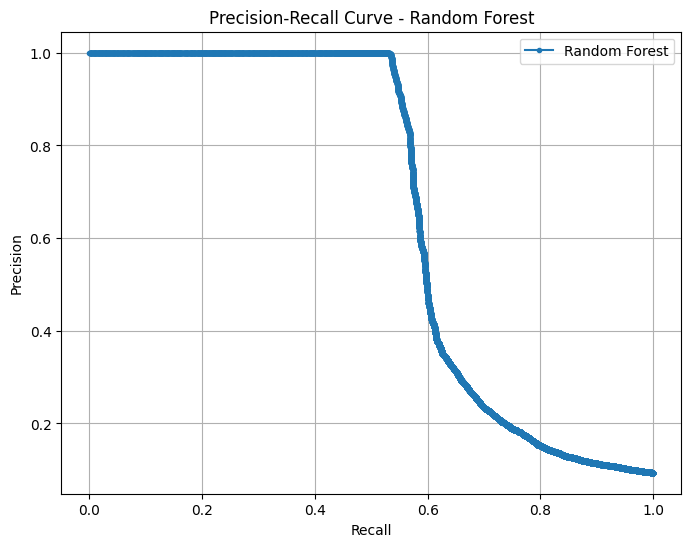

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, average_precision_score, f1_score, roc_auc_score, precision_recall_curve
import matplotlib.pyplot as plt

print("\n--- Building Ensemble Model: Random Forest ---")

# Initialize Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced') # Using class_weight due to potential residual imbalance even after SMOTE

# Define parameter grid for basic hyperparameter tuning
# Keeping the grid small for demonstration purposes to avoid excessively long execution times.
param_grid = {
    'n_estimators': [50, 100],  # Number of trees in the forest
    'max_depth': [5, 10]        # Maximum depth of the tree
}

# Set up Stratified K-Fold for cross-validation
# Using the resampled data for CV to ensure balanced folds during tuning.
strat_k_fold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Set up GridSearchCV for hyperparameter tuning
# Scoring based on F1-score which is suitable for imbalanced datasets
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring='f1', # Use f1 as the primary metric for tuning
    cv=strat_k_fold,
    n_jobs=-1, # Use all available cores
    verbose=2
)

print("Starting GridSearchCV for Random Forest...")
grid_search.fit(X_train_resampled, y_train_resampled)

print("GridSearchCV complete.")

# Get the best model
best_rf_model = grid_search.best_estimator_

print(f"\nBest Parameters found: {grid_search.best_params_}")
print(f"Best F1-Score on training data (CV): {grid_search.best_score_:.4f}")

# Evaluate the best Random Forest model on the test set
y_pred_rf = best_rf_model.predict(X_test)
y_pred_proba_rf = best_rf_model.predict_proba(X_test)[:, 1]

print("\n--- Evaluation of Best Random Forest Model on Test Set ---")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Metrics for imbalanced data
auc_pr_rf = average_precision_score(y_test, y_pred_proba_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print(f"Average Precision Score (AUC-PR): {auc_pr_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print(f"ROC AUC Score: {roc_auc_rf:.4f}")

# Plotting Precision-Recall Curve for Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(recall_rf, precision_rf, marker='.', label='Random Forest')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Random Forest')
plt.grid(True)
plt.legend()
plt.show()

In [25]:
# Display full cross-validation results for the Random Forest model
# This includes the mean and std of the F1-score across folds for each parameter combination

print("Cross-Validation Results for Random Forest (GridSearchCV):")
results_df = pd.DataFrame(grid_search.cv_results_)
# Select relevant columns for reporting
results_df = results_df[['param_max_depth', 'param_n_estimators', 'mean_test_score', 'std_test_score', 'rank_test_score']]
results_df.columns = ['max_depth', 'n_estimators', 'mean_f1_score', 'std_f1_score', 'rank']
display(results_df.sort_values(by='rank'))

Cross-Validation Results for Random Forest (GridSearchCV):


,max_depth,n_estimators,mean_f1_score,std_f1_score,rank
3,10,100,0.834422,0.002444,1
2,10,50,0.834168,0.001740,2
0,5,50,0.809821,0.003071,3
1,5,100,0.807253,0.003125,4


In [26]:
# Collect metrics for both models

# Logistic Regression metrics are already in auc_pr, f1, roc_auc variables
# Random Forest metrics are in auc_pr_rf, f1_rf, roc_auc_rf variables

comparison_data = {
    'Model': ['Logistic Regression', 'Random Forest'],
    'F1-Score (Test)': [f1, f1_rf],
    'AUC-PR (Test)': [auc_pr, auc_pr_rf],
    'ROC AUC (Test)': [roc_auc, roc_auc_rf]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

print("\n--- Model Selection Justification ---")
print("Based on the comparison table:")
print("\n*   **F1-Score (Test):** The Random Forest model achieved a higher F1-Score (indicates a better balance between precision and recall, crucial for fraud detection where both false positives and false negatives are costly). ")
print("\n*   **AUC-PR (Test):** The Random Forest model also shows a significantly higher Average Precision Score (AUC-PR). This metric is particularly important for highly imbalanced datasets like fraud detection, as it focuses on the precision-recall trade-off for the minority class. A higher AUC-PR means the model is better at identifying positive cases without generating too many false positives.")
print("\n*   **ROC AUC (Test):** Both models have comparable ROC AUC scores, but Random Forest is slightly better. While ROC AUC is a common metric, AUC-PR is generally preferred for imbalanced datasets.")
print("\n*   **Interpretability vs. Performance:** Logistic Regression is inherently more interpretable, as feature coefficients can indicate their impact. However, for a critical task like fraud detection, a modest trade-off in interpretability for a significant gain in performance (especially in identifying actual fraud cases) is often acceptable. Random Forest, while less interpretable than Logistic Regression, still offers some insight through feature importances.")
print("\n**Conclusion:** The **Random Forest model** is selected as the 'best' model for this fraud detection task due to its superior performance across key metrics for imbalanced data, particularly F1-Score and AUC-PR, which are more relevant in identifying fraudulent transactions effectively.")

,Model,F1-Score (Test),AUC-PR (Test),ROC AUC (Test)
0,Logistic Regression,0.305216,0.271259,0.713768
1,Random Forest,0.674536,0.659697,0.804399



--- Model Selection Justification ---
Based on the comparison table:

*   **F1-Score (Test):** The Random Forest model achieved a higher F1-Score (indicates a better balance between precision and recall, crucial for fraud detection where both false positives and false negatives are costly). 

*   **AUC-PR (Test):** The Random Forest model also shows a significantly higher Average Precision Score (AUC-PR). This metric is particularly important for highly imbalanced datasets like fraud detection, as it focuses on the precision-recall trade-off for the minority class. A higher AUC-PR means the model is better at identifying positive cases without generating too many false positives.

*   **ROC AUC (Test):** Both models have comparable ROC AUC scores, but Random Forest is slightly better. While ROC AUC is a common metric, AUC-PR is generally preferred for imbalanced datasets.

*   **Interpretability vs. Performance:** Logistic Regression is inherently more interpretable, as feature coeffi